In [39]:
#PART 1: HandInfo.csv EDA 
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# Create a folder to save all our charts into, so we don't lose them
#os.makedirs("eda_outputs", exist_ok=True)

In [40]:
# STEP 1: Load  file

df = pd.read_csv(r"C:\Users\souri\Downloads\Palmistry & Tarot Intelligence\HandInfo.csv", dtype={"id": str})
print("HandInfo.csv loaded. Shape:", df.shape)

# Count dorsal vs palmar images
dorsal_count = df["aspectOfHand"].str.contains("dorsal").sum()
palmar_count = df["aspectOfHand"].str.contains("palmar").sum()

print("Dorsal total:", dorsal_count)
print("Palmar total:", palmar_count)

HandInfo.csv loaded. Shape: (11076, 9)
Dorsal total: 5680
Palmar total: 5396


In [41]:
# STEP 2: Structural check of HandInfo.csv
print("Shape (rows, columns):", df.shape)
print("\nColumn data types:")
print(df.dtypes)

print("\nNumber of missing values per column:")
print(df.isnull().sum())

print("\nNumber of fully duplicated rows:", df.duplicated().sum())
print("Number of duplicate imageName values:", df["imageName"].duplicated().sum())

Shape (rows, columns): (11076, 9)

Column data types:
id                object
age                int64
gender            object
skinColor         object
accessories        int64
nailPolish         int64
aspectOfHand      object
imageName         object
irregularities     int64
dtype: object

Number of missing values per column:
id                0
age               0
gender            0
skinColor         0
accessories       0
nailPolish        0
aspectOfHand      0
imageName         0
irregularities    0
dtype: int64

Number of fully duplicated rows: 0
Number of duplicate imageName values: 0


In [43]:
# STEP 3: Subject-level integrity check
# Does each person (id) always have the same age/gender/skinColor?

subject_check = df.groupby("id").agg({
    "age": "nunique",
    "gender": "nunique",
    "skinColor": "nunique"
})

inconsistent_age = (subject_check["age"] > 1).sum()
inconsistent_gender = (subject_check["gender"] > 1).sum()
inconsistent_skin = (subject_check["skinColor"] > 1).sum()

print("ID with more than one age value:", inconsistent_age)
print("ID with more than one gender value:", inconsistent_gender)
print("ID with more than one skinColor value:", inconsistent_skin)

if inconsistent_age == 0 and inconsistent_gender == 0 and inconsistent_skin == 0:
    print("Every subject has consistent labels across all their images.")
else:
    print("Some subjects have conflicting labels. Investigate before modeling.")

ID with more than one age value: 0
ID with more than one gender value: 0
ID with more than one skinColor value: 0
Every subject has consistent labels across all their images.



=== STEP 4: Categorical column distributions ===

--- gender ---
gender
female    7109
male      3967
Name: count, dtype: int64


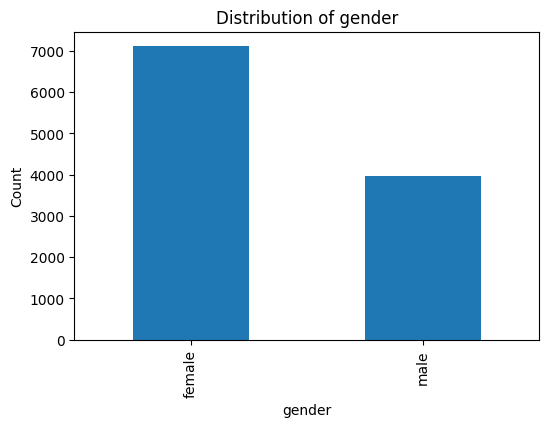


--- skinColor ---
skinColor
medium       6495
fair         3493
dark          758
very fair     330
Name: count, dtype: int64


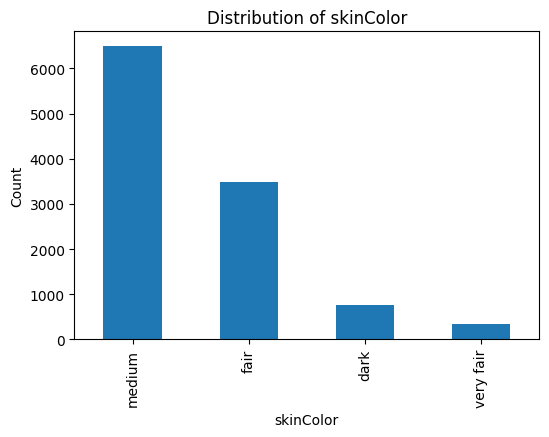


--- aspectOfHand ---
aspectOfHand
dorsal right    2892
palmar right    2813
dorsal left     2788
palmar left     2583
Name: count, dtype: int64


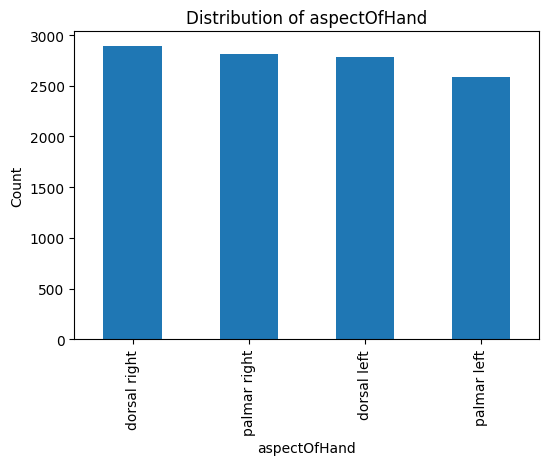


--- accessories ---
accessories
0    7865
1    3211
Name: count, dtype: int64


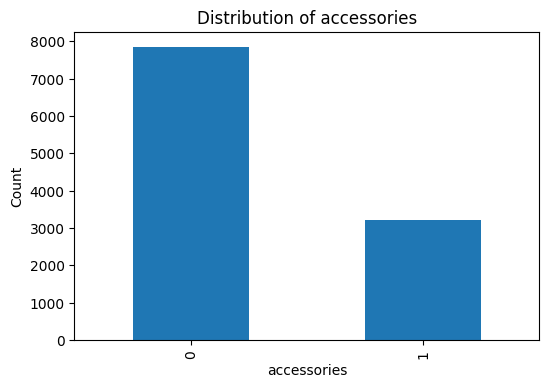


--- nailPolish ---
nailPolish
0    10009
1     1067
Name: count, dtype: int64


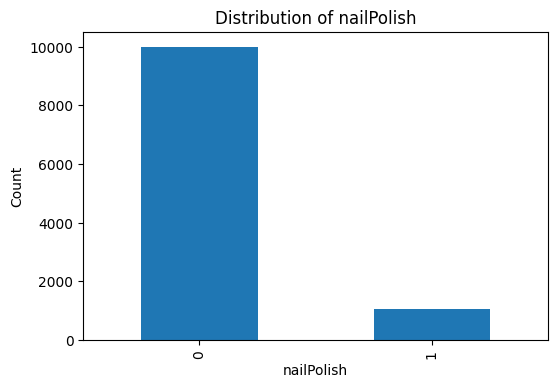


--- irregularities ---
irregularities
0    10912
1      164
Name: count, dtype: int64


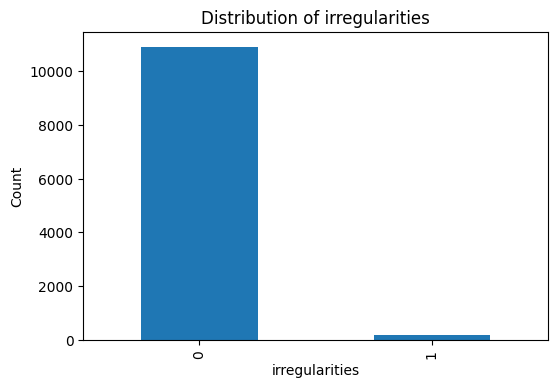

In [34]:
# STEP 4: Univariate distributions - categorical columns

categorical_cols = ["gender", "skinColor", "aspectOfHand", "accessories", "nailPolish", "irregularities"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

    # simple bar chart for each column
    plt.figure(figsize=(6, 4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()
    #plt.tight_layout()
    #plt.savefig(f"eda_outputs/step4_{col}_distribution.png")
    #plt.close()

#print("\nBar charts saved in eda_outputs/ folder.")


=== STEP 5: Age distribution ===
count    11076.000000
mean        22.494583
std          6.918974
min         18.000000
25%         21.000000
50%         21.000000
75%         22.000000
max         75.000000
Name: age, dtype: float64
Skewness of age: 6.3004960099797405


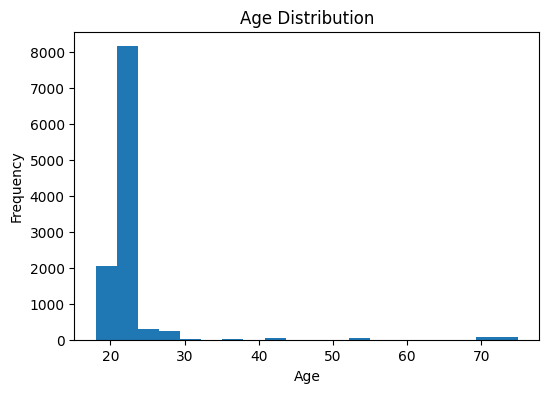

In [35]:
# STEP 5: Univariate distribution - numeric column (age)

print(df["age"].describe())
print("Skewness of age:", df["age"].skew())

plt.figure(figsize=(6, 4))
df["age"].plot(kind="hist", bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
#plt.tight_layout()
#plt.savefig("eda_outputs/step5_age_distribution.png")
#plt.close()
plt.show()



=== STEP 6: Cross-tabulations ===

Gender vs SkinColor:
skinColor  dark  fair  medium  very fair
gender                                  
female      340  2158    4326        285
male        418  1335    2169         45

Gender vs AspectOfHand:
aspectOfHand  dorsal left  dorsal right  palmar left  palmar right
gender                                                            
female               1827          1897         1579          1806
male                  961           995         1004          1007

Age summary grouped by Gender:
         count       mean       std   min   25%   50%   75%   max
gender                                                           
female  7109.0  21.619637  5.863955  18.0  20.0  21.0  21.0  75.0
male    3967.0  24.062516  8.259753  20.0  21.0  22.0  23.0  70.0


<Figure size 600x400 with 0 Axes>

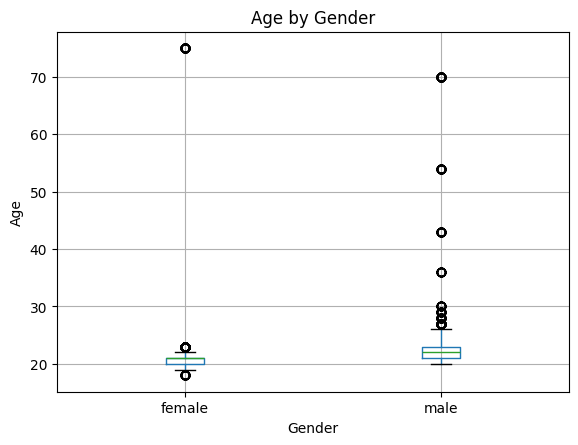

In [44]:
# STEP 6: Bivariate cross-tabs
# ============================================================
print("\n=== STEP 6: Cross-tabulations ===")

print("\nGender vs SkinColor:")
print(pd.crosstab(df["gender"], df["skinColor"]))

print("\nGender vs AspectOfHand:")
print(pd.crosstab(df["gender"], df["aspectOfHand"]))

print("\nAge summary grouped by Gender:")
print(df.groupby("gender")["age"].describe())

# simple boxplot of age by gender
plt.figure(figsize=(6, 4))
df.boxplot(column="age", by="gender")
plt.title("Age by Gender")
plt.suptitle("")  # remove default subtitle
plt.xlabel("Gender")
plt.ylabel("Age")
#plt.tight_layout()
#plt.savefig("eda_outputs/step6_age_by_gender.png")
#plt.close()
plt.show()


=== STEP 7: Images per IDS(data leakage check) ===
count    190.000000
mean      58.294737
std       31.045750
min        1.000000
25%       37.250000
50%       52.000000
75%       74.000000
max      187.000000
dtype: float64


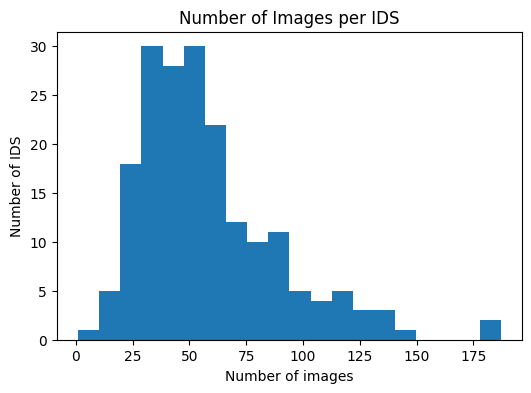


IMPORTANT: Each subject (id) has multiple images.
When you split data into train/test later, split by 'id', NOT by row,
so the same person's hand never appears in both sets.


In [46]:
# STEP 7: Images-per-IDS distribution (leakage check)
# ============================================================
print("\n=== STEP 7: Images per IDS(data leakage check) ===")

images_per_subject = df.groupby("id").size()
print(images_per_subject.describe())

plt.figure(figsize=(6, 4))
images_per_subject.plot(kind="hist", bins=20)
plt.title("Number of Images per IDS")
plt.xlabel("Number of images")
plt.ylabel("Number of IDS")
#plt.tight_layout()
#plt.savefig("eda_outputs/step7_images_per_subject.png")
#plt.close()
plt.show()
print("\nIMPORTANT: Each subject (id) has multiple images.")
print("When you split data into train/test later, split by 'id', NOT by row,")
print("so the same person's hand never appears in both sets.")